这个ipynb的作用：临时评估一些独立的储层的性能，往往这些储层的数据会在其他保存文件中留存。在此处只是快速检测

In [2]:
import os
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle

from pathlib import Path

CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *

In [18]:
## 设置参数
params = ReservoirParams(
        h=0.4, m0=0.03, Nvirt=200, beta_prime=50,
        params={'theta': 0.2, 'gamma': 0.045, 'Nvirt': 200}
    )

# # 评估MC
MC = evaluate_MC(params)
print('MC:', MC)

MC: {'MC': np.float64(5.973888639065236)}


In [8]:
# 设置参数
params = ReservoirParams(
        h=0.4, m0=0.003779957730835859, Nvirt=200, beta_prime=20,
        params={'theta': 0.21914938870841222, 'gamma': 0.0707559779961009, 'Nvirt': 200}
    )

# # 评估MC
# MC = evaluate_MC(params)
# print('MC:', MC)

narma10_dict = {}
# 评估NARMA10
narma10_dict = evaluate_NARMA10(params)

Seed Training: 1234
len(x_train): 2000
error with zero =  0.009066945964734917
0.0077752878930960915 0.7967814126610895


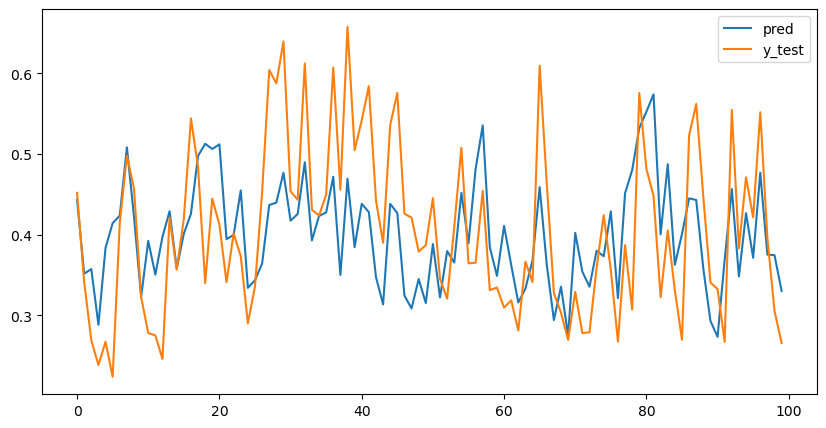

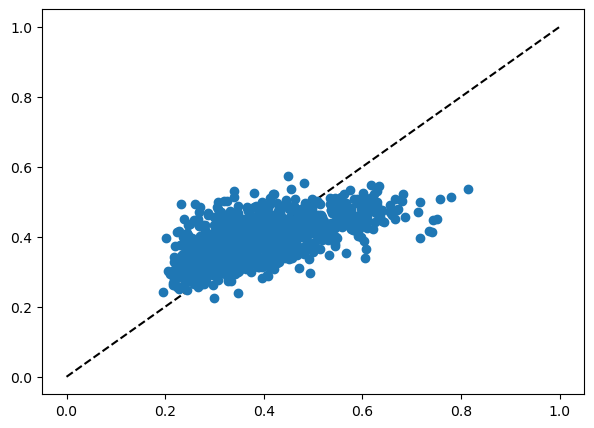

In [12]:
#可视化pred和y_test
plt.figure(figsize=(10, 5))
plt.plot(narma10_dict['pred'][200:300], label='pred')
plt.plot(narma10_dict['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict['y_test'], narma10_dict['pred'], 'o')
plt.show()


In [13]:
# 设置参数
params_3 = ReservoirParams(
        h=0.4, m0=0.007868777052548386, Nvirt=200, beta_prime=20,
        params={'theta': 0.10220030209645715, 'gamma': 0.1327246523368315, 'Nvirt': 200}
    )

# # 评估MC
# MC = evaluate_MC(params)
# print('MC:', MC)

# 评估NARMA10
narma10_dict_3 = {}
narma10_dict_3 = evaluate_NARMA10(params_3)


Seed Training: 1234
len(x_train): 2000
error with zero =  0.004706005872110248
0.005569533434269705 0.6743577652048013


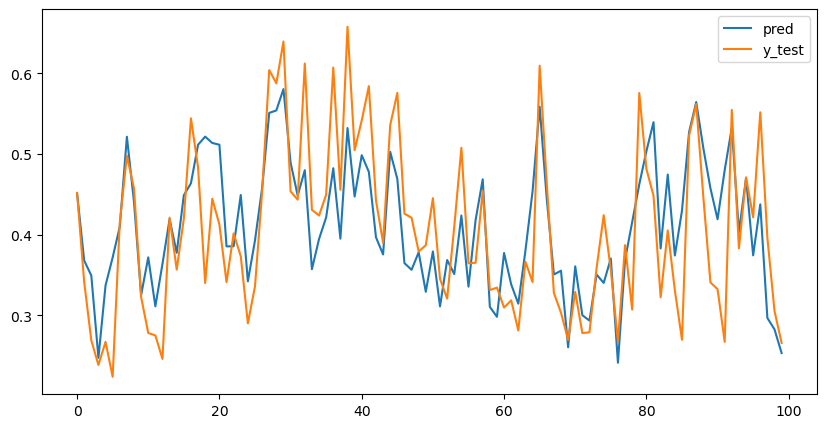

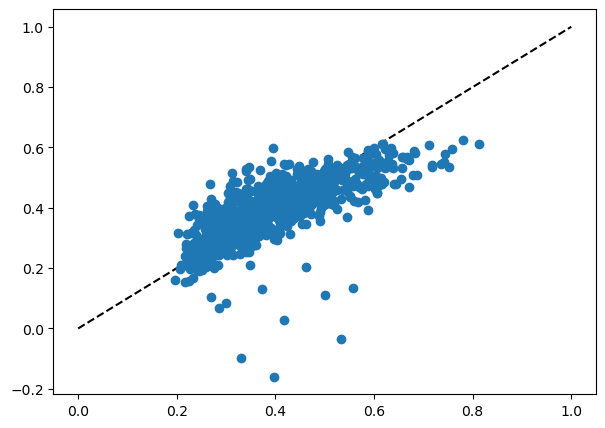

In [14]:
#可视化pred和y_test
plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_3['pred'][200:300], label='pred')
plt.plot(narma10_dict_3['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_3['y_test'], narma10_dict_3['pred'], 'o')
plt.show()

从以上两个储层的表现来看，softgate起到了筛选的作用。

In [15]:
# 评估TI46
acc = evaluate_Ti46(params)
print('TI46 with No204:', acc)

acc_3 = evaluate_Ti46(params_3)
print('TI46 with No3:', acc_3)

Samples for training:  500
first 5 samples for training:  [array([ 0,  0, -1, ...,  0,  0,  0], shape=(12800,), dtype=int16)
 array([ 0,  0,  0, ..., -1,  0,  0], shape=(11520,), dtype=int16)
 array([-1, -1,  0, ...,  0,  0,  1], shape=(16128,), dtype=int16)
 array([-1,  0, -1, ..., -1, -1, -1], shape=(19456,), dtype=int16)
 array([-4, -1,  1, ...,  1,  0,  0], shape=(17152,), dtype=int16)]
Samples for test:  795
Using MFCC preprocessing
Nin = 13 , Nout =  10 , Nvirt =  200
Deterministic mask will be used
the shape of the mask is:  (200, 13)
Seed Training: 1234
len(x_train): 7999
error with zero =  0.07700729697007304
Optimal regression parameter =  1.6487212707000667
Train report
              precision    recall  f1-score   support

           0      0.917     0.825     0.868        40
           1      0.919     0.850     0.883        40
           2      0.838     0.775     0.805        40
           3      0.824     0.700     0.757        40
           4      0.905     0.950     0

额外计算：
目前TI46的结果看起来非常怪，我担心是之前的验证中误改了TI46程序的设定。所以我需要额外重新测试下TI46的结果。以bestMC为例，

In [2]:
# 设置参数 with Nvirt=50
params_bestMC = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=50, beta_prime=50,
        params={'theta': 0.156493838858319, 'gamma': 0.0460842584494091, 'Nvirt': 50}
    )

# 评估TI46
acc_bestMC = evaluate_Ti46(params_bestMC)
print('TI46 with bestMC:', acc_bestMC)


Samples for training:  500
first 5 samples for training:  [array([ 0, -1, -1, ..., -1,  0,  0], shape=(14848,), dtype=int16)
 array([-1,  0,  0, ..., -2, -2, -2], shape=(13056,), dtype=int16)
 array([-1, -1, -1, ...,  2,  1,  1], shape=(13056,), dtype=int16)
 array([ 0, -1,  0, ..., -1, -1, -1], shape=(16640,), dtype=int16)
 array([-1,  0, -1, ...,  0, -1,  0], shape=(12800,), dtype=int16)]
Samples for test:  795
Using MFCC preprocessing
Nin = 13 , Nout =  10 , Nvirt =  50
Deterministic mask will be used
the shape of the mask is:  (50, 13)
Seed Training: 1234
len(x_train): 7999
error with zero =  0.0738574885570247
Optimal regression parameter =  0.0024787521766663234
Train report
              precision    recall  f1-score   support

           0      0.875     0.875     0.875        40
           1      0.917     0.825     0.868        40
           2      0.941     0.800     0.865        40
           3      0.884     0.950     0.916        40
           4      0.909     1.000     0

固定seed版本下，bestMC（Nv=50）的acc为0.63. 已经将TI46程序还原为原始版本（没有seed控制）。之后的acc为0.86

In [3]:
# 再试一次，看看默认情况下trainsignal是否一致
# 设置参数 with Nvirt=50
params_bestMC_new = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=50, beta_prime=50,
        params={'theta': 0.156493838858319, 'gamma': 0.0460842584494091, 'Nvirt': 50}
    )

# 评估TI46
acc_bestMC_new = evaluate_Ti46(params_bestMC_new)
print('TI46 with bestMC:', acc_bestMC)

Samples for training:  500
first 5 samples for training:  [array([ 0, -1, -1, ..., -1,  0,  0], shape=(14848,), dtype=int16)
 array([-1,  0,  0, ..., -2, -2, -2], shape=(13056,), dtype=int16)
 array([-1, -1, -1, ...,  2,  1,  1], shape=(13056,), dtype=int16)
 array([ 0, -1,  0, ..., -1, -1, -1], shape=(16640,), dtype=int16)
 array([-1,  0, -1, ...,  0, -1,  0], shape=(12800,), dtype=int16)]
Samples for test:  795
Using MFCC preprocessing
Nin = 13 , Nout =  10 , Nvirt =  50
Deterministic mask will be used
the shape of the mask is:  (50, 13)
Seed Training: 1234
len(x_train): 7999
error with zero =  0.07368934600300082
Optimal regression parameter =  0.0027394448187683293
Train report
              precision    recall  f1-score   support

           0      0.923     0.900     0.911        40
           1      0.878     0.900     0.889        40
           2      0.938     0.750     0.833        40
           3      0.822     0.925     0.871        40
           4      0.889     1.000     

In [11]:
# 为test_softgate来测试trial263,205,155

# 设置参数
params_263 = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=25.527042007198744,
        params={'theta': 0.01, 'gamma': 0.12157136440484363, 'Nvirt': 200}
    )

# 评估NARMA10
narma10_dict_263 = {}
narma10_dict_263 = evaluate_NARMA10(params_263)

params_205 = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=41.85288952173638,
        params={'theta': 0.24175224854307217, 'gamma': 0.03746068932048024, 'Nvirt': 200}
    )

# 评估NARMA10
narma10_dict_205 = {}
narma10_dict_205 = evaluate_NARMA10(params_205)

params_155 = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=43.81574246502116,
        params={'theta': 0.13457842556468863, 'gamma': 0.04094224711144865, 'Nvirt': 200}
    )

# 评估NARMA10
narma10_dict_155 = {}   
narma10_dict_155 = evaluate_NARMA10(params_155)

Seed Training: 1234
len(x_train): 2000
error with zero =  0.018966855792228336
0.04349055861043648 1.8844232244742751
Seed Training: 1234
len(x_train): 2000
error with zero =  0.0066713631678427445
0.013980539306397454 1.068422234802184
Seed Training: 1234
len(x_train): 2000
error with zero =  0.005861630102618311
0.012404131545203353 1.0063849574272168


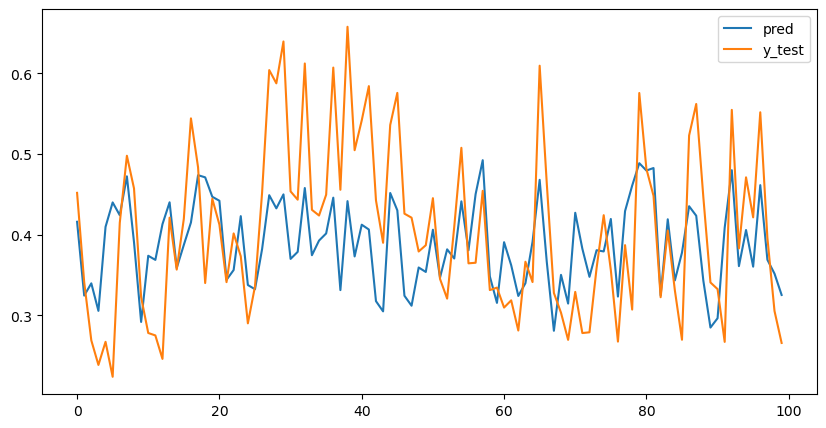

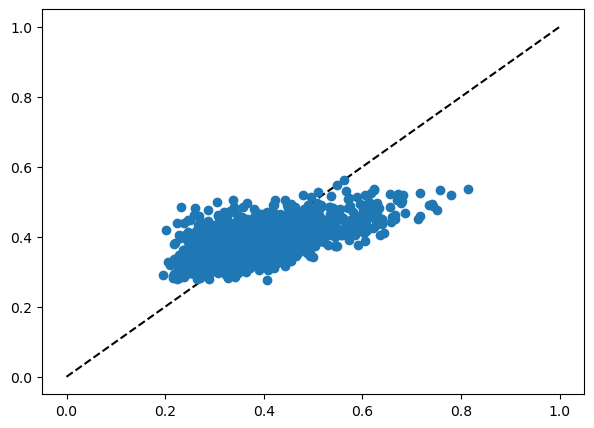

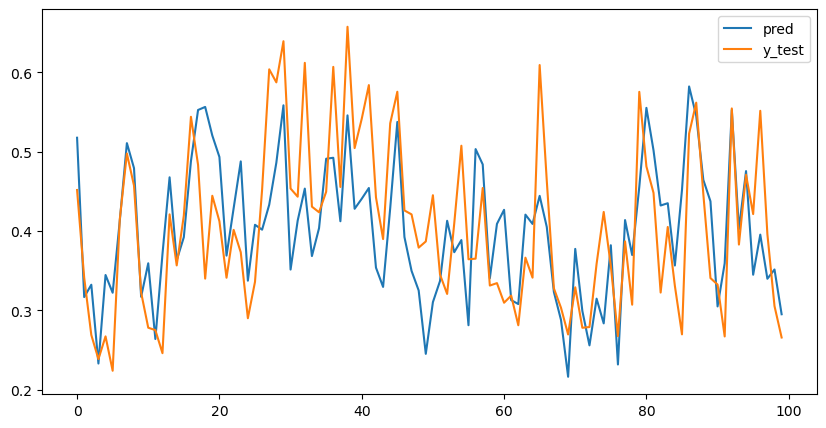

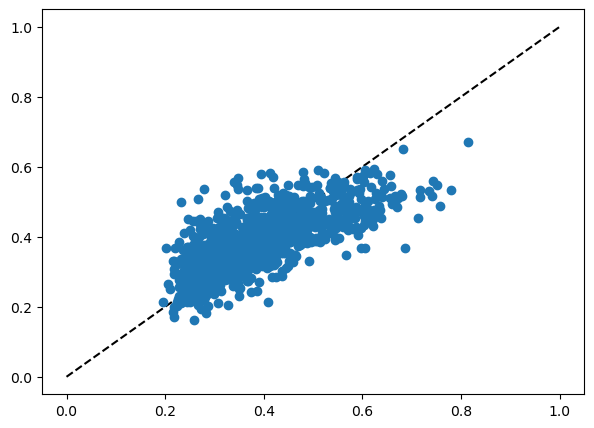

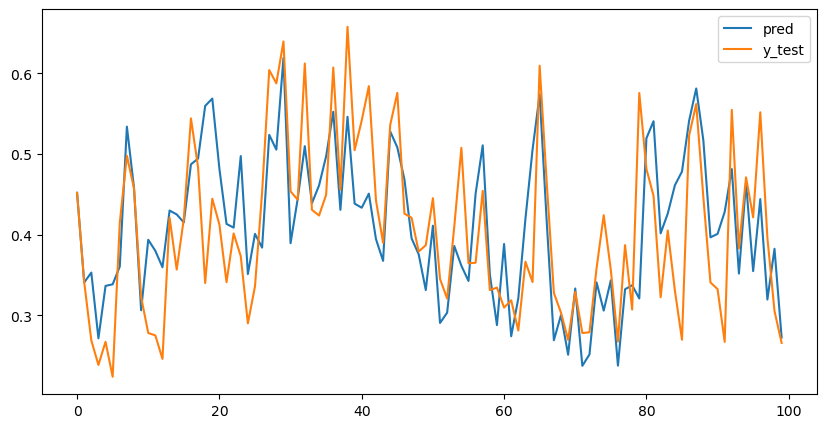

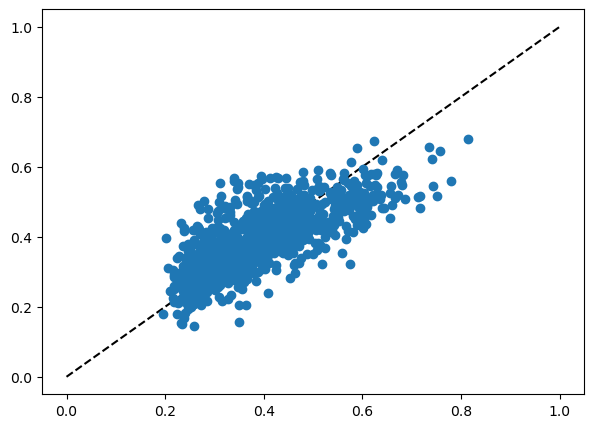

In [12]:
#可视化pred和y_test
plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_263['pred'][200:300], label='pred')
plt.plot(narma10_dict_263['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_263['y_test'][10:], narma10_dict_263['pred'][10:], 'o')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_205['pred'][200:300], label='pred')
plt.plot(narma10_dict_205['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_205['y_test'][10:], narma10_dict_205['pred'][10:], 'o')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_155['pred'][200:300], label='pred')
plt.plot(narma10_dict_155['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_155['y_test'][10:], narma10_dict_155['pred'][10:], 'o')
plt.show()


In [13]:
def MSE(pred, desired):
    return np.mean(np.square(np.subtract(pred, desired)))

def NRMSE(pred, y_test, spacer=0.001):
    return np.sqrt(MSE(pred, y_test) / np.var(y_test))


nrmse_263 = NRMSE(narma10_dict_263['pred'][10:], narma10_dict_263['y_test'][10:])

print(f"NRMSE of trial263: {nrmse_263:.3f}")

nrmse_205 = NRMSE(narma10_dict_205['pred'][10:], narma10_dict_205['y_test'][10:])

print(f"NRMSE of trial205: {nrmse_205:.3f}")

nrmse_155 = NRMSE(narma10_dict_155['pred'][10:], narma10_dict_155['y_test'][10:])

print(f"NRMSE of trial155: {nrmse_155:.3f}")


NRMSE of trial263: 0.789
NRMSE of trial205: 0.726
NRMSE of trial155: 0.698


Seed Training: 1234
len(x_train): 2000
error with zero =  0.0034728789011267544
0.0079011083657748 0.8032023384482746
Seed Training: 1234
len(x_train): 2000
error with zero =  0.003314311687157189
0.01611245194109277 1.1469956545364046


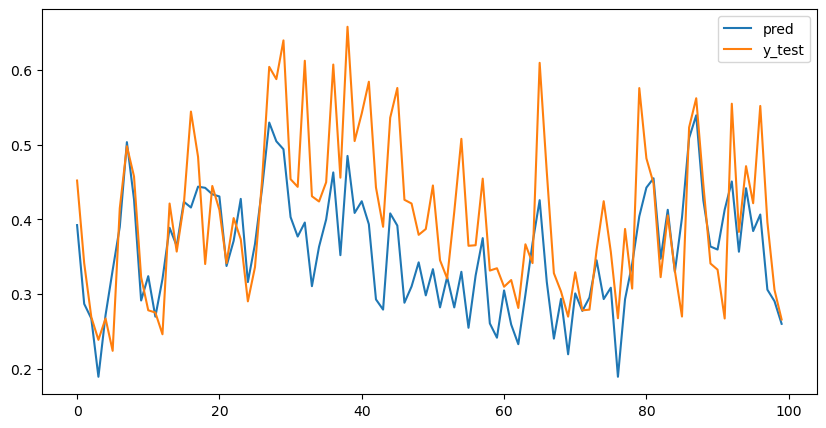

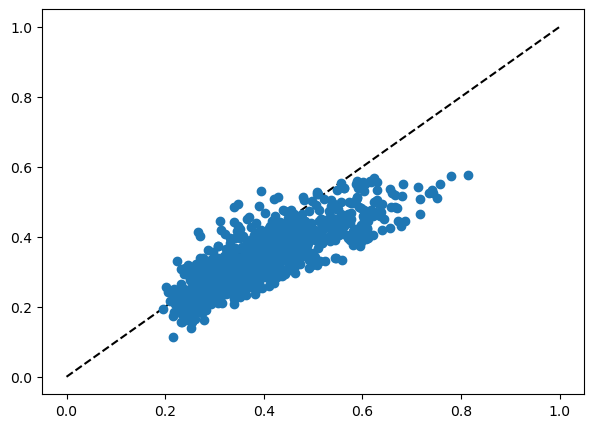

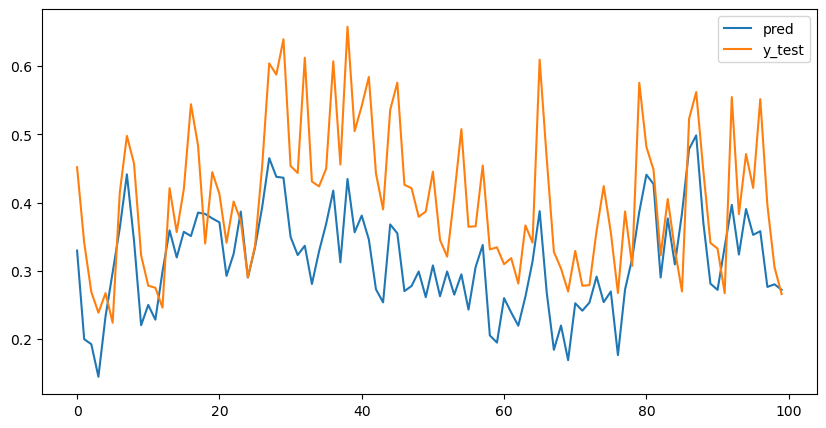

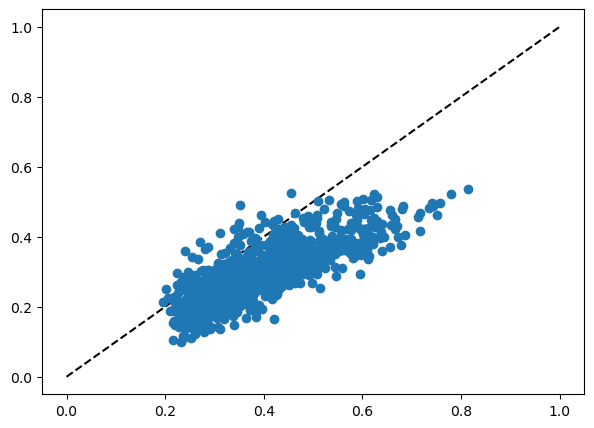

In [ ]:
# 对比‘result_dict_beta50’中的42和43
# 设置参数
params_42 = ReservoirParams(
        h=0.4, m0=0.0561155135769405, Nvirt=200, beta_prime=50,
        params={'theta': 0.2, 'gamma': 0.0533878749591413, 'Nvirt': 200}
    )

# 评估NARMA10
narma10_dict_42 = {}
narma10_dict_42 = evaluate_NARMA10(params_42)

params_43 = ReservoirParams(
        h=0.4, m0=0.060112674154498, Nvirt=200, beta_prime=50,
        params={'theta': 0.2, 'gamma': 0.0578430239725703, 'Nvirt': 200}
    )

# 评估NARMA10
narma10_dict_43 = {}
narma10_dict_43 = evaluate_NARMA10(params_43)

plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_42['pred'][200:300], label='pred')
plt.plot(narma10_dict_42['y_test'][200:300], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_42['y_test'][10:], narma10_dict_42['pred'][10:], 'o')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_43['pred'], label='pred')
plt.plot(narma10_dict_43['y_test'], label='y_test')
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot( np.linspace(0.0,1.0), np.linspace(0.0,1.0), 'k--')
plt.plot(narma10_dict_43['y_test'][10:], narma10_dict_43['pred'][10:], 'o')
plt.show()



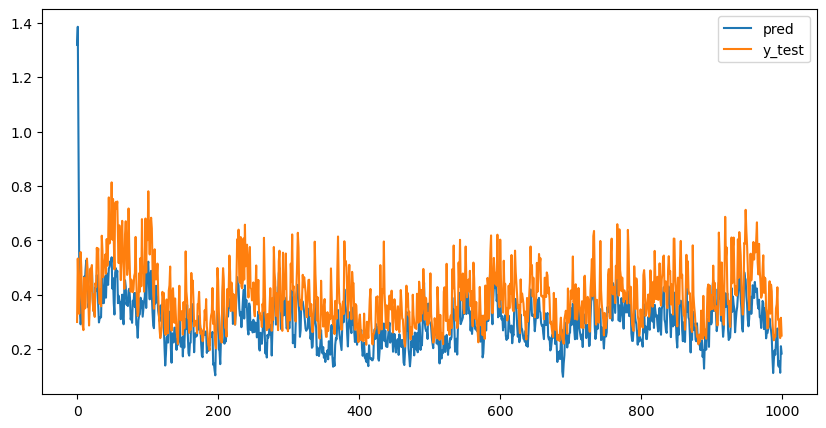

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(narma10_dict_43['pred'], label='pred')
plt.plot(narma10_dict_43['y_test'], label='y_test')
plt.legend()
plt.show()

In [ ]:
nrmse_42    = NRMSE(narma10_dict_42['pred'][10:], narma10_dict_42['y_test'][10:])

print(f"NRMSE of trial42: {nrmse_42:.3f}")

nrmse_43 = NRMSE(narma10_dict_43['pred'][10:], narma10_dict_43['y_test'][10:])

print(f"NRMSE of trial43: {nrmse_43:.3f}") 



NRMSE of trial42: 0.766
NRMSE of trial43: 1.068
